In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


**Import libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as xp

**Explore data**

In [3]:
df = pd.read_csv('/kaggle/input/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Notes:**
 - unusuful cols: PassengerId, Name, Ticket
 - categorical: Survived, Pclass, Sex, SibSp, Parch, Embarked
 - numerical: age, fare
 - target: survived

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**missing data: age, Cabin, Embarked**
* if missing > 40% ----> delete col
* if missing < 5% -----> drop missing 

In [5]:
df['Cabin'].value_counts()

B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: Cabin, Length: 147, dtype: int64

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Data cleaning**

In [7]:
df.duplicated().sum()

0

**Drop unecessary cols**

In [8]:
df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

In [9]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Null values**

In [10]:
df.dropna(subset=["Embarked"], inplace=True)

In [11]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

<AxesSubplot:>

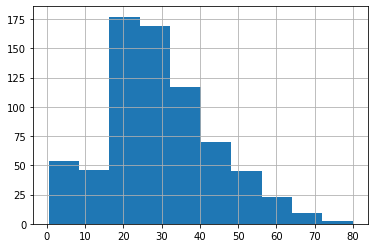

In [12]:
df.Age.hist()

In [13]:
df[df['Sex']=='female'].Age.median()

27.0

In [14]:
df[df['Sex']=='male'].Age.median()

29.0

In [15]:
df[(df["Pclass"]==1) & (df["Sex"]=="female")].Age.median()

35.0

In [16]:
df[(df["Pclass"]==1) & (df["Sex"]=="male")].Age.median()

40.0

In [17]:
df.groupby(["Pclass", "Sex"])["Age"].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

## Logic:
  - loop through all rows 
  - get Pclass, Sex -----> set median

In [18]:
c1_f = 35
c1_m = 40
c2_f = 28
c2_m = 30
c3_f = 21.5
c3_m = 25

def fill_age(row):
    if pd.isnull(row["Age"]):
        if row["Pclass"] == 1 and row["Sex"] == "female":
            return c1_f
        elif row["Pclass"] == 1 and row["Sex"] == "male":
            return c1_m
        elif row["Pclass"] == 2 and row["Sex"] == "female":
            return c2_f
        elif row["Pclass"] == 2 and row["Sex"] == "male":
            return c2_m
        elif row["Pclass"] == 3 and row["Sex"] == "female":
            return c3_f
        elif row["Pclass"] == 3 and row["Sex"] == "male":
            return c3_m

df["Age"] = df.apply(lambda row: fill_age(row), axis=1)

## Solution2 to fill the missing data on age

In [19]:
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].apply(lambda row: row.fillna(row.median()))

In [20]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# rename columns

In [21]:
df.columns = df.columns.str.lower()

In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,25.0,1,0,7.2500,S
1,1,1,female,35.0,1,0,71.2833,C
2,1,3,female,21.5,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,25.0,0,0,8.0500,S


## univarirate analysis

In [23]:
(df["survived"].value_counts()/len(df)) * 100

0    61.754781
1    38.245219
Name: survived, dtype: float64

## 61% dead
## 38% survived

<AxesSubplot:>

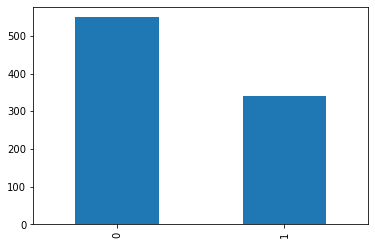

In [24]:
df["survived"].value_counts().plot(kind="bar")

<AxesSubplot:xlabel='survived', ylabel='count'>

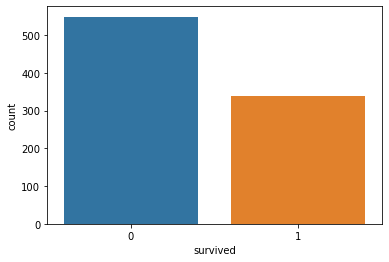

In [25]:
sns.countplot(x="survived", data=df)

In [26]:
df["pclass"].value_counts(normalize=True)

3    0.552306
1    0.240720
2    0.206974
Name: pclass, dtype: float64

## Notes:
 - 55% class  3 
 - 20  class  2
 - 24% class  1

<AxesSubplot:xlabel='pclass', ylabel='count'>

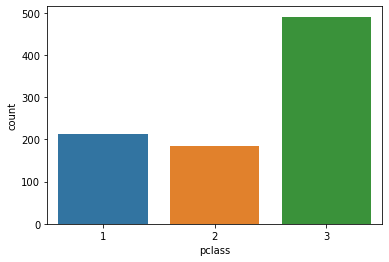

In [27]:
sns.countplot(x="pclass", data=df)

## function to visualize categorical cols

In [28]:
def visualize_categorical_cols(df, col):
    print(f"\n column: {col}")
    print(df[col].value_counts(normalize=True))
    sns.countplot(x=col, data=df)
    plt.show()
    

In [29]:
cols = ["sex", "sibsp", "parch", "embarked"]


 column: sex
male      0.649044
female    0.350956
Name: sex, dtype: float64


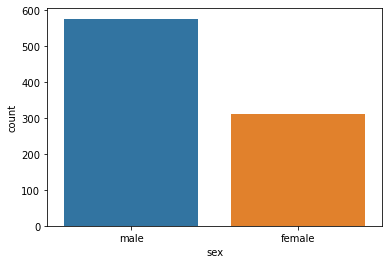


 column: sibsp
0    0.681665
1    0.235096
2    0.031496
4    0.020247
3    0.017998
8    0.007874
5    0.005624
Name: sibsp, dtype: float64


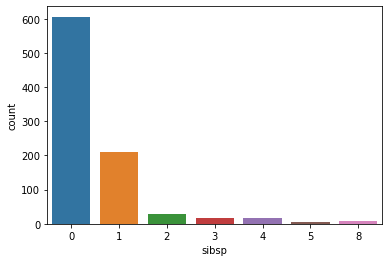


 column: parch
0    0.760405
1    0.132733
2    0.089989
5    0.005624
3    0.005624
4    0.004499
6    0.001125
Name: parch, dtype: float64


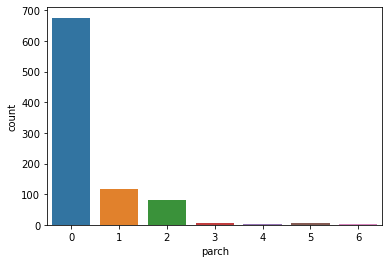


 column: embarked
S    0.724409
C    0.188976
Q    0.086614
Name: embarked, dtype: float64


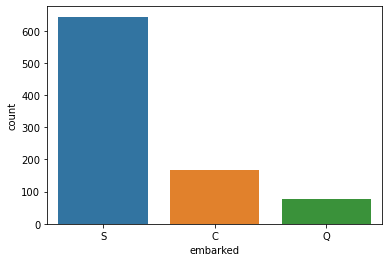

In [30]:
for c in cols:
    visualize_categorical_cols(df, c)

# Notes:
    - 60% have no siblings
    - 76% no parch
    - 72% embarked from S

-------------

## Visualize number cols

In [31]:
def visualize_numeric_cols(df, col):
    print(f"\n column: {col}")
    print(df[col].value_counts(normalize=True))
    sns.histplot(x=col, data=df)
    plt.show()

In [32]:
cols = ["age", "fare"]


 column: age
25.0    0.390326
21.5    0.161980
40.0    0.137233
30.0    0.121485
35.0    0.103487
28.0    0.085489
Name: age, dtype: float64


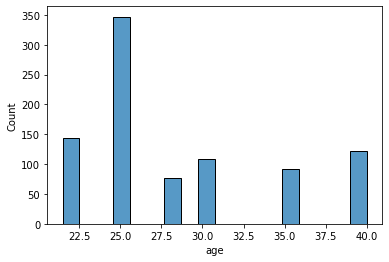


 column: fare
8.0500     0.048369
13.0000    0.047244
7.8958     0.042745
7.7500     0.038245
26.0000    0.034871
             ...   
35.0000    0.001125
28.5000    0.001125
6.2375     0.001125
14.0000    0.001125
10.5167    0.001125
Name: fare, Length: 247, dtype: float64


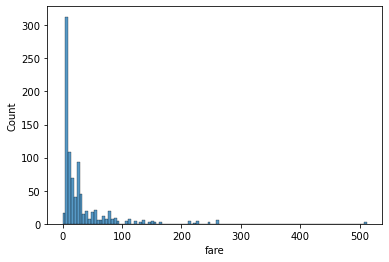

In [33]:
for c in cols:
    visualize_numeric_cols(df, c)

# Notes:
 - majority of people has less than 40
 - age range : 15-40
 - majority fare: 0 to 100

---------

## Bivariate analysis

In [34]:
df.sample()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
155,0,1,male,40.0,0,1,61.3792,C


In [35]:
df.groupby("pclass").survived.mean()

pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

# Notes:
    - in the first class you have a chance to live of 62%
    - in the second class you have a chance to live of 47%
    - in the third class you have a chance to live of 24%

<AxesSubplot:xlabel='pclass', ylabel='survived'>

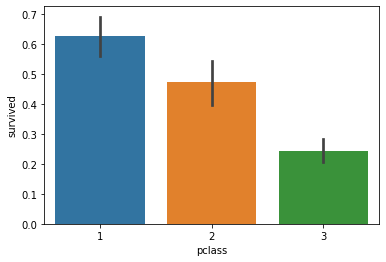

In [36]:
sns.barplot(x='pclass', y="survived", data=df)

<AxesSubplot:xlabel='survived', ylabel='count'>

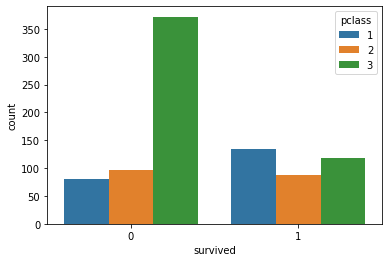

In [37]:
sns.countplot(x="survived", hue="pclass", data=df)

## using plotly

In [38]:
fig = xp.bar(df, x= "pclass", y="survived", barmode="group", color="survived",title="survived per class")
fig.show()

## Survival per col

In [39]:
def visualize_rate_col(df, col):
    print(f"coluln: {col}")
    print(df.groupby(df.groupby(col).survived.mean()))
    sns.barplot(x=col, y='survived', data=df)
    plt.axhline(df.survived.mean(), linestyle="--")
    plt.show()

coluln: pclass


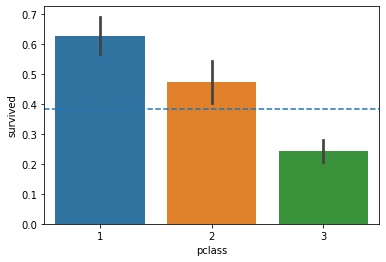

coluln: sex


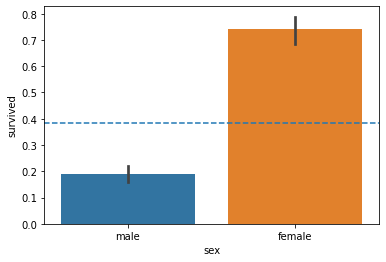

coluln: sibsp


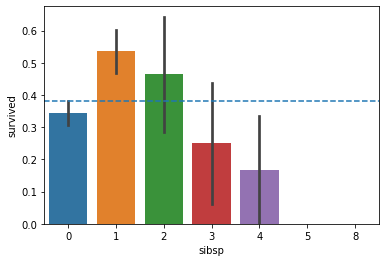

coluln: parch


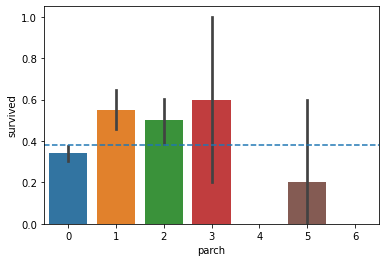

coluln: embarked


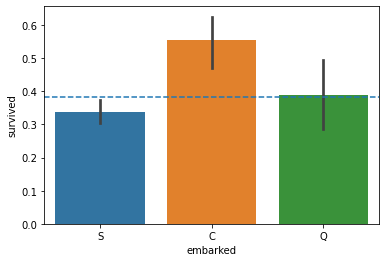

In [40]:
cols = ["pclass", "sex", "sibsp", "parch", "embarked"]

for c in cols:
    visualize_rate_col(df, c)

## Multivariant analysis

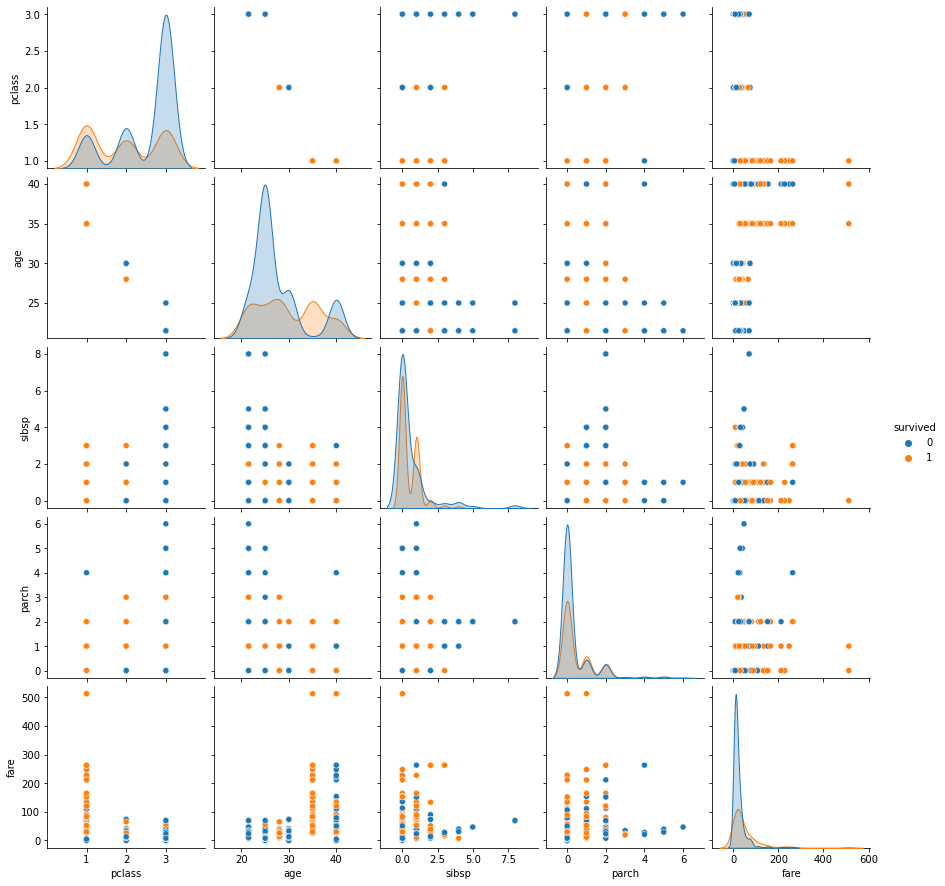

In [41]:
sns.pairplot(data=df, hue="survived")

## Correlation

In [42]:
df.corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,0.176811,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.948631,0.081656,0.016824,-0.548193
age,0.176811,-0.948631,1.000000,-0.110423,-0.083612,0.501524
sibsp,-0.034040,0.081656,-0.110423,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.083612,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.501524,0.160887,0.217532,1.000000


<AxesSubplot:>

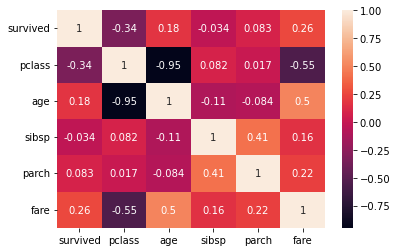

In [43]:
sns.heatmap(df.corr(), annot=True)

In [44]:
df.corr()["survived"]

survived    1.000000
pclass     -0.335549
age         0.176811
sibsp      -0.034040
parch       0.083151
fare        0.255290
Name: survived, dtype: float64

---------

# Final report:
 - the higher the class ---> high surviver rate
 - females have a high survival rate comparing to man